In [5]:
"""
this notebook will show simple implementations of Time Series Models, including some good ways to preprocess the data 
whereafter We will do analysis, and perform short term forecasts
"""

'\nthis notebook will show simple implementations of Time Series Models, including some good ways to preprocess the data \nwhereafter We will do analysis, and perform short term forecasts\n'

# Data Fetching & Preprocessing

In [18]:
import yfinance as yf
import pandas as pd
from typing import Union, List
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Functions

def fetch_stock_data_close(tickers: Union[str, List[str]], period: str = "7d", interval: str = "1m") -> pd.DataFrame:
    """
    Fetches historical stock data and isolates the 'Close' prices for modeling.

    Parameters:
    -----------
    tickers : str or list of str
        The stock ticker symbol(s) to fetch. Examples: "AAPL" or ["TSLA", "NVDA"].
    period : str
        The time period to download data for. 
        Valid options: "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y", "5y", "10y", "ytd", "max".
    interval : str
        The frequency of the data points. 
        Valid options: "1m", "2m", "5m", "15m", "30m", "60m", "90m", "1h", "1d", "5d", "1wk", "1mo", "3mo".
        Note: "1m" data is heavily restricted by Yahoo Finance and only available for the last 7 days.

    Returns:
    --------
    pd.DataFrame
        A clean DataFrame containing only the closing prices for the requested tickers,
        indexed by datetime. 
    """
    # Standardize input: convert a single string to a list so the logic below always works
    if isinstance(tickers, str):
        tickers = [tickers]

    print(f"Fetching {interval} data for {tickers} over the last {period}...")
    
    # Download data. By default, yfinance puts 'Close', 'Open', etc. at the top level
    data = yf.download(tickers, period=period, interval=interval)
    
    # Dynamically extract 'Close' prices based on the number of tickers provided
    if len(tickers) == 1:
        close_prices = data[['Close']].copy()
        close_prices.columns = [f"{tickers[0]}_Close"]
    else:
        close_prices = data['Close'].copy()
        # Dynamically rename columns to explicitly show they are close prices
        close_prices.columns = [f"{ticker}_Close" for ticker in close_prices.columns]
        
    # Drop rows with missing values to ensure a clean dataset
    close_prices.dropna(inplace=True)
    
    return close_prices


In [8]:
target_stocks = ["TSLA","NVDA"]
my_stocks_daily = fetch_stock_data_close(tickers=target_stocks, period="5y", interval="1d")

Fetching 1d data for ['TSLA', 'NVDA'] over the last 5y...


[*********************100%***********************]  2 of 2 completed


In [19]:
my_stocks_daily.tail(2)

,NVDA_Close,TSLA_Close
Date,,
2026-04-09,183.910004,345.619995
2026-04-10,188.229996,344.114990


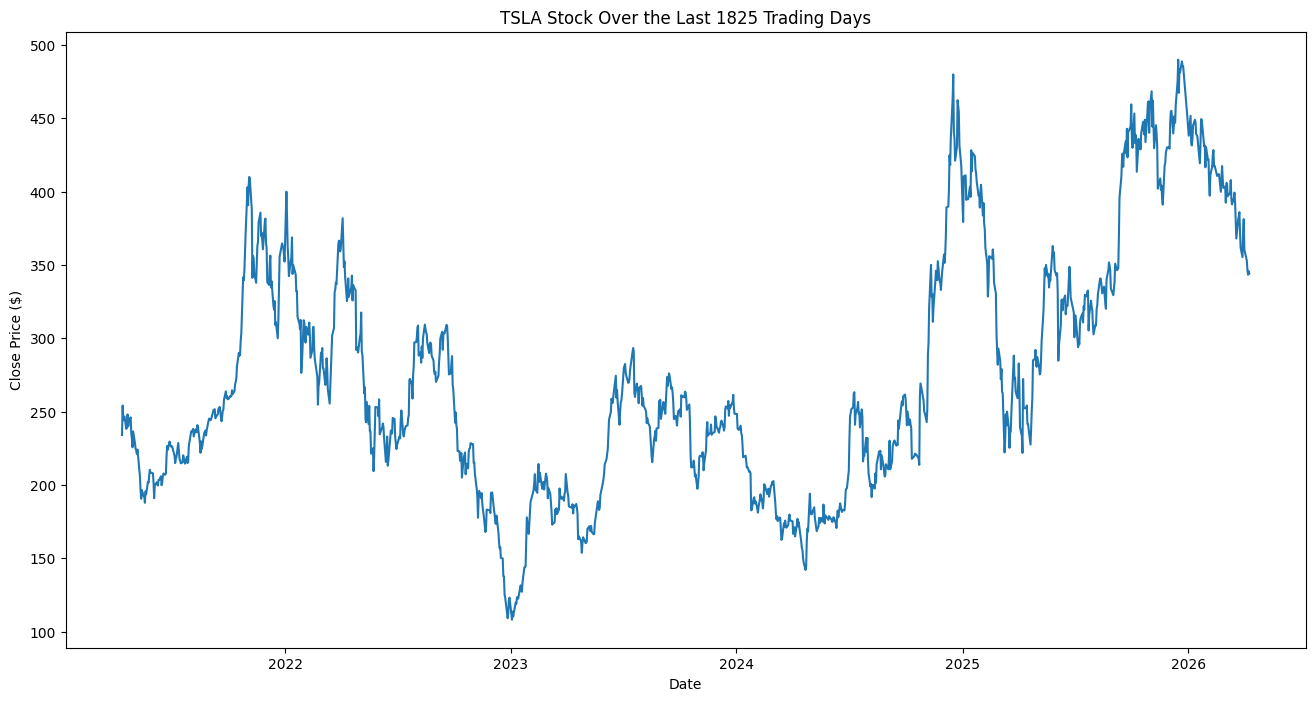

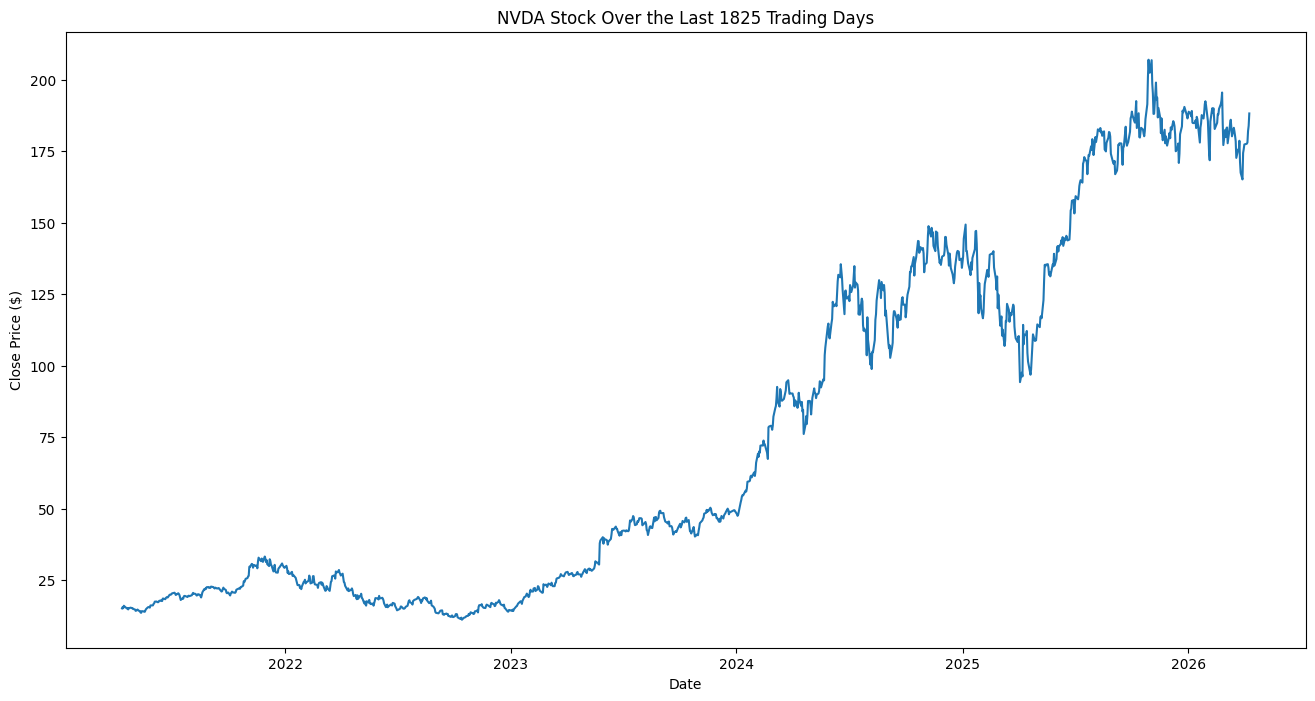

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_stock(ticker="TSLA", time_days=900, save=False):
    plt.figure(figsize=(16, 8))
    
    # Note: Since financial data drops weekends, 'time_days' represents trading days.
    # 900 trading days is roughly 3.5 calendar years.
    plt.title(f"{ticker} Stock Over the Last {time_days} Trading Days")
    plt.ylabel("Close Price ($)")
    
    # 1. Dynamically build the column name using the ticker argument
    column_name = f"{ticker}_Close"
    
    # 2. Slice the DataFrame to get only the last 'time_days' rows
    data_to_plot = my_stocks_daily[column_name].tail(time_days)
    
    # 3. Plot the dynamically selected and sliced data
    sns.lineplot(data=data_to_plot)

    if save: 
        # Using a raw f-string (rf) handles path slashes safely
        plt.savefig(rf"time_series_plots/{ticker}_{time_days}_days.png", dpi=300)
        print(f"Plot saved as {ticker}_{time_days}_days.png")
        
    # Explicitly display the plot
    plt.show()

# --- Example Usage ---
plot_stock(ticker="TSLA", time_days=5*365) # Plots roughly 1 year of TSLA
plot_stock(ticker="NVDA", time_days=5*365) # Plots roughly 2 years of NVDA

# Pre flight checks

# Dumb Questions.

In [37]:
# How long would it take for a person that has 1000 Dollars to his name, earning 1% every day to become the richest man alive.

In [39]:
# Recall the exponential function from high school.
# A = P * (1+r)^n 
# Where A:final amount  , P: Principal/ initial investment, r: interest rate , n is the time duration (days, years, eons)


In [ ]:
def compound_interest(P,r,n):
    return P*(1+r)^n 

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Initial variables
n = 5 * 365 # 5 years (1825 days)
P = 1000
r = 0.01

# Vectorized approach: calculate wealth for every day at once
days = np.arange(1, n + 1)
value_over_time = P * (1 + r)**days
# Simple as that

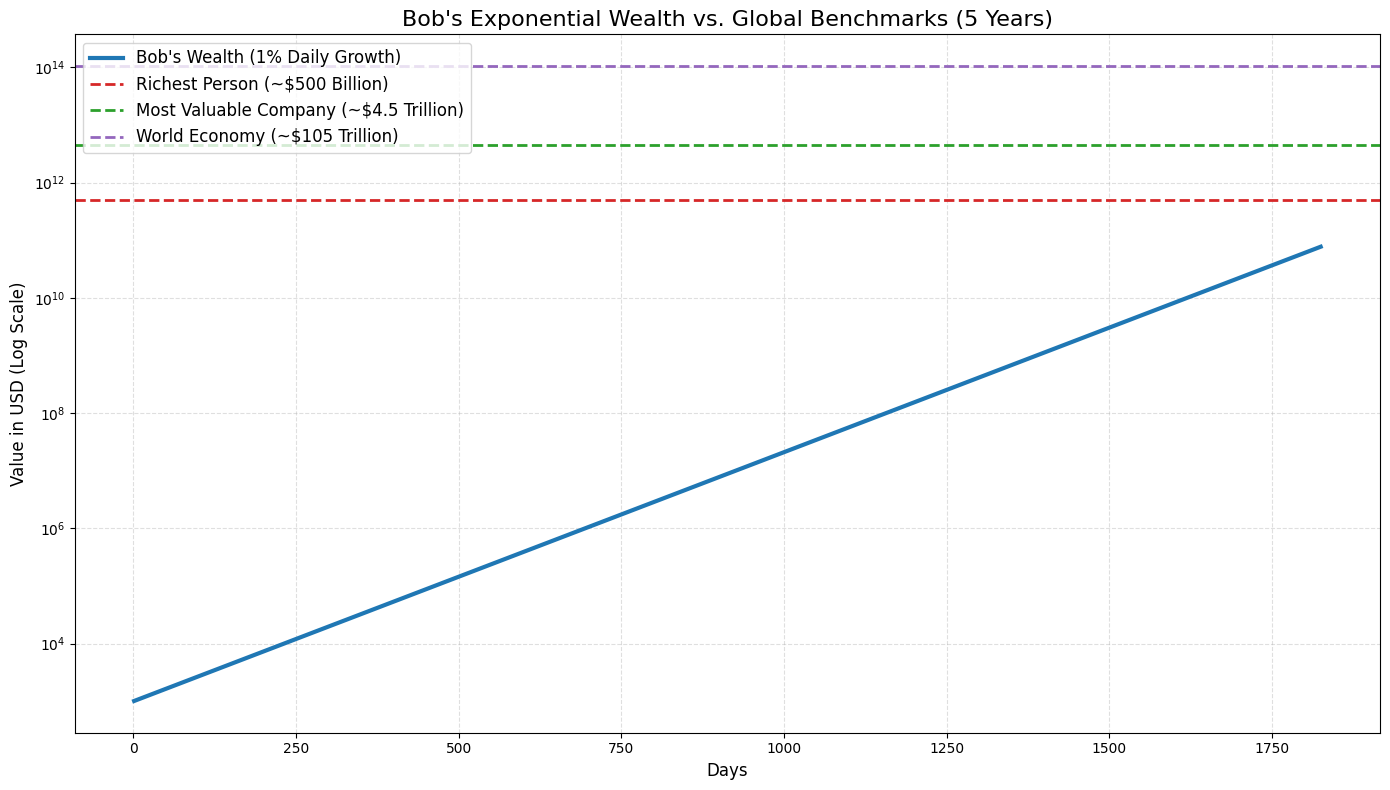

In [ ]:
# comparing to some powerhouses
# Financial Benchmarks (approximate current USD)
richest_person = 500 * 10**9     # ~$200 Billion 
valuable_company = 4.5 * 10**12    # ~$3 Trillion 
world_gdp = 105 * 10**12         # ~$105 Trillion

# Setup Plot
plt.figure(figsize=(14, 8))

# Plot Bob's wealth
plt.plot(days, value_over_time, label="Bob's Wealth (1% Daily Growth)", color="#2513CA", linewidth=3)

# Add Benchmark lines
plt.axhline(y=richest_person, color='#d62728', linestyle='--', linewidth=2, label="Richest Person (~$500 Billion)")
plt.axhline(y=valuable_company, color='#2ca02c', linestyle='--', linewidth=2, label="Most Valuable Company (~$4.5 Trillion)")
plt.axhline(y=world_gdp, color='#9467bd', linestyle='--', linewidth=2, label="World Economy (~$105 Trillion)")

# Formatting
plt.yscale('log') # Crucial for exponential growth visualization
plt.title("Bob's Exponential Wealth vs. Global Benchmarks (5 Years)", fontsize=16)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Value in USD (Log Scale)", fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig("bobs_exponential_wealth.png", dpi=300)

In [73]:
# After 5 years of Bob sitting on his ass, he has managed to come close to Elons net worth (in log terms), 
# his net worth in USD is now 77 Billion USD, so 
print(f"Bobs net worth after 5 years: {value_over_time[-1]}")
print(f"Elon is at this time {richest_person/value_over_time[-1]} times richer than Bob")


Bobs net worth after 5 years: 77002912750.55359
Elon is at this time 6.4932608668937055 times richer than Bob


The Question becomes, When will Bob overtake Elon, Be more valuable than the most valuable Company (NVDA), and even the World Economy . (Assuming all of them remain as they are)
* We can simply utilize the properties that the log of an exponential function is a simple linear function. 
* A quick study should be able to see from the plot above that Bob is soon on the verge of world domination 

In [ ]:
# Again for some high school math 
bobs_value_logged = np.log(value_over_time)
# recall from high school that we can find the slope of a linear function 

a = $\frac{\Delta(y)}{\Delta(x)}$ , and we can choose any two points where the index is i , and i+1 


In [ ]:
bobs_value_logged = bobs_value_logged.tolist()

In [101]:
slope = (bobs_value_logged[1500]- bobs_value_logged[1499])/(1) 
intercept = bobs_value_logged[0]
# Ignore Jensen's Inequality!

In [103]:
def bobs_log_value_pred(intercept,slope,day_no):
    return intercept + slope*day_no

In [107]:
import math
def find_day_to_hit_target(target_y, intercept, slope):
    """
    Finds the exact day (x) when Bob's wealth hits a target value (y).
    """
    # 1. Transform the target into log space
    log_target = math.log(target_y)
    
    # 2. Rearrange: x = (log(y) - intercept) / slope
    exact_day = (log_target - intercept) / slope
    
    # Return rounded up, since he hits it during that day
    return math.ceil(exact_day)

In [ ]:
bobs_log_value_pred(intercept,slope,10*365)


43.236413223901295

In [112]:
find_day_to_hit_target(target_y= richest_person, intercept = intercept, slope= slope)

2013

In [110]:
find_day_to_hit_target(target_y= world_gdp, intercept = intercept, slope= slope)

2550

$\textbf{Conclusion}: $ Bob is the richest man in the world after 2013 days, And overtakes the world economy after 2550 days!